In [1]:
"""Cell 1: Imports + load"""
import sys, pathlib
import pandas as pd

sys.path.insert(0, str(pathlib.Path("../src").resolve()))
from data_loader import load_raw, validate

DATA_PATH = pathlib.Path("../data/raw/mmm_example.csv")
df = load_raw(DATA_PATH)
ok, errors = validate(df)
print(f"Shape: {df.shape}")
print(f"Date range: {df['date_week'].min()} → {df['date_week'].max()}")
print(f"Valid: {ok} | Errors: {errors}")

Shape: (179, 8)
Date range: 2018-04-02 00:00:00 → 2021-08-30 00:00:00
Valid: True | Errors: []


In [2]:
"""Cell 2: Info + describe"""
df.info()
df.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date_week  179 non-null    datetime64[us]
 1   y          179 non-null    float64       
 2   x1         179 non-null    float64       
 3   x2         179 non-null    float64       
 4   event_1    179 non-null    float64       
 5   event_2    179 non-null    float64       
 6   dayofyear  179 non-null    int64         
 7   t          179 non-null    int64         
dtypes: datetime64[us](1), float64(5), int64(2)
memory usage: 11.3 KB


,date_week,y,x1,x2,event_1,event_2,dayofyear,t
count,179,179.00,179.00,179.00,179.00,179.00,179.00,179.00
mean,2019-12-16 00:00:00,5284.95,0.31,0.16,0.01,0.01,182.60,89.00
min,2018-04-02 00:00:00,3192.88,0.00,0.00,0.00,0.00,4.00,0.00
25%,2019-02-07 12:00:00,4484.22,0.15,0.00,0.00,0.00,103.00,44.50
50%,2019-12-16 00:00:00,5163.39,0.27,0.00,0.00,0.00,181.00,89.00
75%,2020-10-22 12:00:00,5941.28,0.40,0.00,0.00,0.00,262.50,133.50
max,2021-08-30 00:00:00,8312.41,1.00,0.99,1.00,1.00,365.00,178.00
std,NaN,1087.28,0.24,0.35,0.07,0.07,100.37,51.82


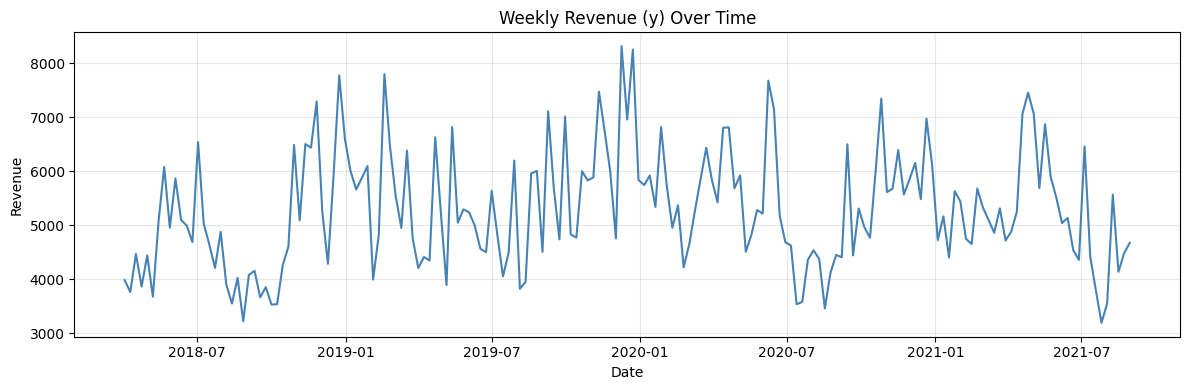

In [3]:
"""Cell 3: Revenue time series"""
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date_week"], df["y"], linewidth=1.5, color="steelblue")
ax.set_title("Weekly Revenue (y) Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

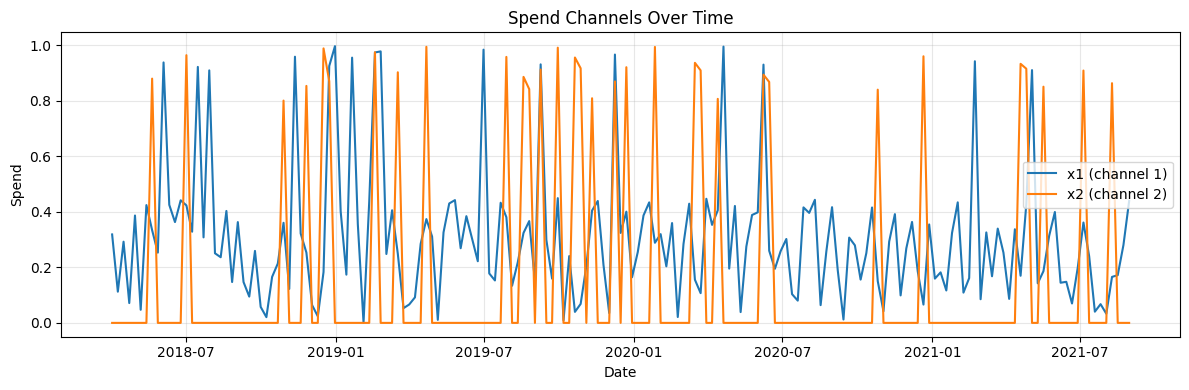

In [4]:
"""Cell 4: Spend channels over time"""
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date_week"], df["x1"], label="x1 (channel 1)", linewidth=1.5)
ax.plot(df["date_week"], df["x2"], label="x2 (channel 2)", linewidth=1.5)
ax.set_title("Spend Channels Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Spend")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

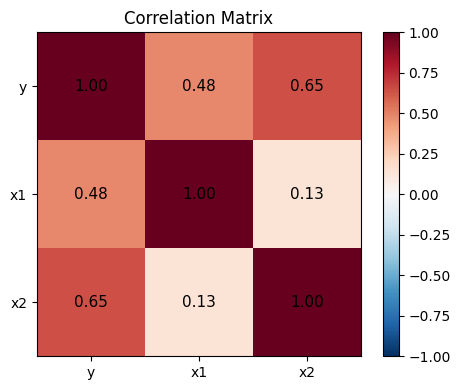

In [5]:
"""Cell 5: Correlation heatmap"""
import numpy as np

cols = ["y", "x1", "x2"]
corr = df[cols].corr().values

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
fig.colorbar(im, ax=ax)
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols)
ax.set_yticklabels(cols)
ax.set_title("Correlation Matrix")
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=11)
fig.tight_layout()
plt.show()

## EDA Summary

### Data Quality
- 179 weekly observations (2018-04-02 → 2021-08-30), no missing values
- Dates are monotonically increasing; `validate()` returns no errors

### Observations
- **Revenue (y)**: Shows seasonal patterns with periodic spikes, suggesting event-driven uplift
- **Channels (x1, x2)**: Both spend channels vary week-to-week; x2 tends to be higher in absolute spend
- **Correlations**: x1 and x2 show moderate positive correlation with y — consistent with expected media effect
- **Event flags**: `event_1` and `event_2` mark specific promotional periods worth including as covariates

### Next Steps (Phase 3 — Modeling)
1. Fit PyMC-Marketing `MMM` model with adstock + saturation transforms on x1, x2
2. Compare against Stan baseline (manual adstock)
3. Channel allocation sensitivity analysis via posterior samples